# Assignment 19: Word2Vec Text Embeddings

## Objective

The goal of this assignment is to understand Word Embeddings and implement the Word2Vec algorithm using the SMS Spam Collection dataset.

Unlike traditional vectorization techniques such as One-Hot Encoding, Bag of Words, and TF-IDF, Word2Vec learns dense vector representations that capture semantic relationships between words.

In this assignment, we will:

- Understand the concept of word embeddings.
- Learn the intuition behind Word2Vec.
- Compare CBOW and Skip-Gram architectures.
- Train Word2Vec models using Gensim.
- Explore word similarity and vector operations.
- Visualize learned word embeddings.

## Dataset

**Dataset:** SMS Spam Collection Dataset

**Source:** Kaggle

https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset

# Task 1: Understanding Word Embeddings

## 1. What are Word Embeddings?

Word embeddings are dense numerical vector representations of words in a continuous vector space. Instead of representing each word independently, embeddings place words with similar meanings close to one another. This allows machine learning models to capture semantic relationships and contextual information between words.

---

## 2. Why do One-Hot Encoding and Bag of Words fail to capture semantics?

One-Hot Encoding and Bag of Words treat every word as an independent feature without considering its meaning or context. They cannot identify synonyms, semantic similarity, or relationships between words. For example, the words **good** and **excellent** are represented as completely unrelated features even though they convey similar meanings.

---

## 3. How do Word Embeddings solve these problems?

Word embeddings learn vector representations by analyzing the contexts in which words appear. Words that frequently occur in similar contexts receive similar vector representations. As a result, semantically related words are positioned close together in the embedding space, allowing models to better understand language meaning and relationships.

# Task 2: Word2Vec Overview

Word2Vec is a neural network-based technique developed by Google for learning word embeddings. Instead of representing words as sparse vectors (such as in One-Hot Encoding or Bag of Words), Word2Vec learns dense, continuous vector representations that capture semantic meaning and contextual relationships between words.

The main idea behind Word2Vec is that words appearing in similar contexts tend to have similar meanings. During training, the model learns these relationships by predicting words based on their neighboring words within a sentence.

For example, in the sentence:

> "The cat is sleeping on the sofa."

the word **cat** frequently appears near words like **sleeping**, **sofa**, and **pet**. Over many sentences, Word2Vec learns that words such as **cat** and **dog** often appear in similar contexts, so their vector representations become close in the embedding space.

## Important Terminology

### 1. Vocabulary

The vocabulary is the collection of all unique words present in the dataset after preprocessing.

Example:

Sentence 1:
```
the cat is sleeping
```

Sentence 2:
```
the dog is barking
```

Vocabulary:

```
the, cat, is, sleeping, dog, barking
```

Vocabulary Size = **6**

### 2. Context Window

The context window determines how many neighboring words are considered while learning a target word.

For example, if the sentence is:

```
the cat is sleeping peacefully
```

Suppose the target word is:

```
is
```

If **window = 2**, the context words are:

```
cat, the, sleeping, peacefully
```

A larger window captures broader context, while a smaller window focuses on nearby words.

### 3. Embedding Dimension

The embedding dimension refers to the length of the numerical vector used to represent each word.

For example:

```
cat → [0.42, -0.18, 0.71, ..., 0.09]
```

If the embedding dimension is **100**, every word is represented by a vector containing **100 numerical values**.

Higher dimensions can capture more semantic information but require more memory and training time. In this assignment, we will use an embedding dimension of **100**.

# Task 3: Types of Word2Vec Techniques

Word2Vec provides two different training approaches for learning word embeddings:

1. Continuous Bag of Words (CBOW)
2. Skip-Gram

Although both models produce word embeddings, they differ in how they learn from text.

## 1. Continuous Bag of Words (CBOW)

### Definition

CBOW predicts the **target word** using its surrounding context words.

For example, consider the sentence:

```
The cat is sleeping peacefully
```

If the target word is:

```
is
```

The context words are:

```
The, cat, sleeping, peacefully
```

CBOW uses the surrounding words to predict the missing target word.

### Example

Input (Context Words):

```
The, cat, sleeping, peacefully
```

Output (Target Word):

```
is
```

### Advantages

- Faster to train than Skip-Gram.
- Works well on large datasets.
- Produces good embeddings for frequently occurring words.

### When to Use CBOW

CBOW is preferred when working with large datasets and when faster training is required. Since it predicts one word from multiple surrounding words, it is computationally efficient and performs well for common words.

## 2. Skip-Gram

### Definition

Skip-Gram performs the opposite task of CBOW. Instead of predicting the target word, it uses the **target word** to predict its surrounding context words.

Using the same sentence:

```
The cat is sleeping peacefully
```

If the target word is:

```
is
```

The model predicts:

```
The
cat
sleeping
peacefully
```

### Example

Input (Target Word):

```
is
```

Output (Context Words):

```
The
cat
sleeping
peacefully
```

### Advantages

- Produces better word embeddings for rare words.
- Captures semantic relationships more effectively.
- Often achieves higher accuracy than CBOW.

### When to Use Skip-Gram

Skip-Gram is preferred when the dataset is relatively small or when learning high-quality embeddings for infrequent words is important. Although it requires more training time, it generally produces richer semantic representations.

## CBOW vs Skip-Gram

| Feature | CBOW | Skip-Gram |
|----------|------|-----------|
| Predicts | Target word from context | Context words from target word |
| Training Speed | Faster | Slower |
| Performance on Frequent Words | Better | Good |
| Performance on Rare Words | Average | Better |
| Suitable for | Large datasets | Small datasets and rare words |
| Computational Cost | Lower | Higher |

### Summary

Both CBOW and Skip-Gram learn meaningful word embeddings by analyzing word context. CBOW is computationally efficient and suitable for large datasets, while Skip-Gram is better at learning representations for rare words and capturing semantic relationships, making it a popular choice when embedding quality is the primary objective.

# Task 4: Neural Network Intuition Behind Word2Vec

Word2Vec uses a shallow neural network to learn meaningful vector representations of words. Unlike deep neural networks with many hidden layers, Word2Vec consists of only one hidden layer and is trained to predict words based on their context.

During training, the network gradually adjusts its weights so that words appearing in similar contexts obtain similar vector representations. After training is complete, the weights of the hidden layer become the learned word embeddings.

## Architecture of Word2Vec

A simple Word2Vec neural network consists of three layers:

```
             Input Layer
                  │
                  ▼
        Hidden (Embedding) Layer
                  │
                  ▼
             Output Layer
```

- **Input Layer:** Receives the input word (or context words).
- **Hidden Layer:** Learns a dense numerical representation (embedding) of each word.
- **Output Layer:** Predicts the target word (CBOW) or the surrounding context words (Skip-Gram).

The learned weights between the input layer and the hidden layer form the final word embeddings.

## How Word2Vec Learns

The learning process can be summarized as follows:

1. The input word (or context words) is provided to the neural network.
2. The hidden layer converts the input into a dense vector representation.
3. The output layer predicts the target word or surrounding context words.
4. The prediction error is calculated.
5. The network updates its weights using backpropagation.
6. This process repeats for all words across multiple training iterations.

After many iterations, words that appear in similar contexts develop similar embedding vectors.

## Example

Consider the sentence:

```
The cat is sleeping peacefully
```

### CBOW

Input:

```
The, cat, sleeping, peacefully
```

Output:

```
is
```

### Skip-Gram

Input:

```
is
```

Output:

```
The
cat
sleeping
peacefully
```

During training, the neural network continuously adjusts its weights until it can accurately predict the target words. These learned weights become the word embeddings used in NLP applications.

### Observations

- Word2Vec uses a shallow neural network with a single hidden layer.
- The hidden layer learns dense vector representations of words.
- Similar words receive similar embeddings because they appear in similar contexts.
- The learned embedding vectors can be used for tasks such as text classification, sentiment analysis, document clustering, and semantic similarity.

# Task 5: Preparing Data for Word2Vec

Before training the Word2Vec model, the text data must be converted into a list of tokenized sentences.

Each sentence is represented as a list of words. This is the format required by the Gensim Word2Vec implementation.

In this task, we will:

- Import the required library.
- Convert the cleaned text into tokenized sentences.
- Verify the structure of the prepared data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from gensim.models import Word2Vec
from sklearn.decomposition import PCA

In [4]:
df=pd.read_csv('spam.csv', encoding='latin-1')

In [5]:
df=df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"])
df.columns=["label","text"]
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
import re

In [7]:
def remove_repeated_characters(text):
    return re.sub(r"(.)\1{2,}", r"\1\1", text)

In [8]:
slang_dict = {
    "u": "you",
    "ur": "your",
    "pls": "please",
    "msg": "message",
    "luv": "love",
    "thx": "thanks",
    "thanx": "thanks",
    "tmr": "tomorrow",
    "gr8": "great",
    "wat": "what",
    "wif": "with",
    "gud": "good",
    "nite": "night",
    "coz": "because",
    "c": "see",
    "txt": "text",
    "wk": "week",
    "wkly": "weekly",
    "mins": "minutes",
    "ya": "yeah",
    "yae": "yeah",
    "lor": "lord",
    "da": "the",
    "oso": "also"
}

In [9]:
def replace_slang(text):
    words = text.split()
    updated_words = []
    for word in words:
        if word in slang_dict:
            updated_words.append(slang_dict[word])
        else:
            updated_words.append(word)
    return " ".join(updated_words)

In [10]:
import nltk
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

In [11]:
def remove_stopwords(text):
    words = text.split()
    filtered_words = []
    for word in words:
        if word not in stop_words:
            filtered_words.append(word)
    return ' '.join(filtered_words)

In [12]:
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

In [13]:
from nltk.tokenize import word_tokenize
def lemmatize_text(text):
    words = word_tokenize(text)
    lemmatized_words = [lemmatizer.lemmatize(word) for word in words]
    return " ".join(lemmatized_words)

In [14]:
def nlp_preprocess(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\S+@\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    text = remove_repeated_characters(text)
    text = replace_slang(text)
    text = remove_stopwords(text)
    text = lemmatize_text(text)
    return text

In [15]:
df["final_clean_text"] = df["text"].apply(nlp_preprocess)

In [16]:
df.shape
df.info()
df[["label", "text", "final_clean_text"]].head()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   label             5572 non-null   str  
 1   text              5572 non-null   str  
 2   final_clean_text  5572 non-null   str  
dtypes: str(3)
memory usage: 855.4 KB


,label,text,final_clean_text
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry weekly comp win fa cup final tkts s...
3,ham,U dun say so early hor... U c already then say...,dun say early hor see already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think go usf life around though


In [18]:
sentences = df["final_clean_text"].str.split()
sentences.head()

0    [go, jurong, point, crazy, available, bugis, n...
1                               [ok, lar, joking, oni]
2    [free, entry, weekly, comp, win, fa, cup, fina...
3            [dun, say, early, hor, see, already, say]
4    [nah, dont, think, go, usf, life, around, though]
Name: final_clean_text, dtype: object

In [19]:
sentences = sentences.tolist()
print("Data Type:", type(sentences))
print("Number of Sentences:", len(sentences))

Data Type: <class 'list'>
Number of Sentences: 5572


In [20]:
for i in range(5):
    print(f"Sentence {i+1}:")
    print(sentences[i])
    print()

Sentence 1:
['go', 'jurong', 'point', 'crazy', 'available', 'bugis', 'n', 'great', 'world', 'la', 'e', 'buffet', 'cine', 'got', 'amore']

Sentence 2:
['ok', 'lar', 'joking', 'oni']

Sentence 3:
['free', 'entry', 'weekly', 'comp', 'win', 'fa', 'cup', 'final', 'tkts', 'st', 'may', 'text', 'fa', 'receive', 'entry', 'questionstd', 'text', 'ratetcs', 'apply', 'over']

Sentence 4:
['dun', 'say', 'early', 'hor', 'see', 'already', 'say']

Sentence 5:
['nah', 'dont', 'think', 'go', 'usf', 'life', 'around', 'though']



In [21]:
sentence_lengths = [len(sentence) for sentence in sentences]

print("Average Sentence Length:", round(np.mean(sentence_lengths), 2))
print("Shortest Sentence:", min(sentence_lengths))
print("Longest Sentence:", max(sentence_lengths))

Average Sentence Length: 8.63
Shortest Sentence: 0
Longest Sentence: 80


### Observations

- The cleaned SMS messages were successfully converted into tokenized sentences.
- Each sentence is represented as a Python list of words, which is the required input format for Gensim's Word2Vec model.
- The dataset contains sentences of varying lengths, providing diverse contextual information for learning word embeddings.

# Task 6: Training the CBOW Word2Vec Model

In this task, we train a Word2Vec model using the Continuous Bag of Words (CBOW) architecture.

CBOW predicts the target word using its surrounding context words. During training, the model learns dense vector representations (embeddings) for every word in the vocabulary.

We will:
- Train the CBOW model.
- Measure the training time.
- Explore the learned vocabulary.
- Inspect the embedding vector of a sample word.

In [35]:
start_time_cbow = time.time()

cbow_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=0
)

end_time_cbow = time.time()

print(f"Training Time: {end_time_cbow - start_time_cbow:.2f} seconds")

Training Time: 0.25 seconds


In [23]:
print("Vocabulary Size:", len(cbow_model.wv))

Vocabulary Size: 7830


In [24]:
list(cbow_model.wv.index_to_key[:20])

['call',
 'im',
 'get',
 'text',
 'go',
 'good',
 'dont',
 'free',
 'ok',
 'ltgt',
 'å',
 'know',
 'day',
 'got',
 'come',
 'like',
 'see',
 'please',
 'ill',
 'love']

In [25]:
word = "free"

print(f"Embedding for '{word}':\n")
print(cbow_model.wv[word])

Embedding for 'free':

[-0.22726437  0.4489155  -0.05925395  0.02381372 -0.01397473 -0.7670189
  0.06341776  0.8763779  -0.12577477 -0.3335069  -0.22153327 -0.6561286
 -0.11429399  0.17920633  0.02746532 -0.34963396 -0.00397546 -0.5151474
  0.05022022 -0.89116067  0.37009028  0.19925417  0.17954825 -0.29182857
 -0.17953537  0.15607934 -0.256061   -0.24961887 -0.47984505  0.04166618
  0.47576228  0.12450691  0.08679277 -0.20659149 -0.14106251  0.73829997
  0.05233298 -0.44401717 -0.35207164 -0.72313726  0.12835357 -0.49765497
 -0.16166873  0.06374379  0.46654794 -0.19307095 -0.26800656 -0.10246634
  0.25617215  0.3426737   0.335412   -0.35565484 -0.18287602 -0.05743047
 -0.35145023  0.20309319  0.24946937  0.01532945 -0.42926913  0.03325085
  0.17248668  0.27252588 -0.08309906 -0.02588599 -0.39513883  0.46591163
  0.252898    0.26945648 -0.5646807   0.6513152  -0.31027493  0.1477311
  0.38510934 -0.06772666  0.434181    0.37522915  0.04159402 -0.06957091
 -0.49022657  0.11482578 -0.3608

In [26]:
print(cbow_model.wv["free"].shape)

(100,)


In [27]:
cbow_summary = pd.DataFrame({
    "Metric": [
        "Vocabulary Size",
        "Embedding Dimension",
        "Training Architecture"
    ],
    "Value": [
        len(cbow_model.wv),
        cbow_model.vector_size,
        "CBOW"
    ]
})

cbow_summary

,Metric,Value
0,Vocabulary Size,7830
1,Embedding Dimension,100
2,Training Architecture,CBOW


### Observations

- The CBOW model was successfully trained on the SMS Spam Collection dataset.
- The model learned a dense 100-dimensional vector representation for every word in the vocabulary.
- Each embedding captures semantic information based on the contexts in which the word appears.
- These learned vectors can now be used to measure word similarity and perform various NLP tasks.

# Task 7: Training the Skip-Gram Model

In this task, we train a Word2Vec model using the Skip-Gram architecture.

Unlike CBOW, which predicts a target word from its surrounding context, Skip-Gram predicts the surrounding context words from a target word.

Although Skip-Gram generally takes longer to train, it often produces better embeddings for infrequent words.

In [37]:
start_time = time.time()

skipgram_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=1
)

end_time = time.time()

print(f"Training Time: {end_time - start_time:.2f} seconds")

Training Time: 0.44 seconds


In [29]:
print("Vocabulary Size:", len(skipgram_model.wv))

Vocabulary Size: 7830


In [30]:
word = "free"

print(f"Embedding for '{word}':\n")
print(skipgram_model.wv[word])

Embedding for 'free':

[ 0.214058    0.2990837   0.0758758   0.0628204  -0.16762784 -0.5549879
  0.02335598  0.7874138   0.2041981  -0.5108923  -0.04514351 -0.28535149
  0.24837705  0.06156109  0.0136654  -0.10892227  0.073565   -0.2735803
 -0.07947525 -0.7514641   0.29324648  0.14195308  0.22857562 -0.13320154
 -0.2595274   0.13663785  0.10564481 -0.0570607  -0.5028248  -0.12065774
  0.04124111  0.1944337   0.15825878 -0.25162324  0.09959452  0.69470507
  0.11150025 -0.57603294 -0.43965343 -0.00224108  0.03356971 -0.21538651
 -0.08997989 -0.17932501  0.35018575 -0.03545383 -0.14482893 -0.11809337
  0.38100603  0.19310229 -0.01424609 -0.22025682 -0.02387375 -0.07099681
 -0.5579195   0.38078812 -0.10384835  0.28468063 -0.22834429 -0.04920192
  0.08426151  0.16745627 -0.05383373  0.15196006  0.0593718   0.56055367
 -0.19236864  0.13979785 -0.19221763  0.13594042  0.04983288  0.3382139
  0.3826994   0.05836643  0.1893941   0.48639044  0.44153333 -0.15669163
  0.0977882   0.18117596 -0.463

In [31]:
print(skipgram_model.wv["free"].shape)

(100,)


In [32]:
skipgram_summary = pd.DataFrame({
    "Metric": [
        "Vocabulary Size",
        "Embedding Dimension",
        "Training Architecture"
    ],
    "Value": [
        len(skipgram_model.wv),
        skipgram_model.vector_size,
        "Skip-Gram"
    ]
})

skipgram_summary

,Metric,Value
0,Vocabulary Size,7830
1,Embedding Dimension,100
2,Training Architecture,Skip-Gram


In [38]:
comparison = pd.DataFrame({
    "Feature": [
        "Training Time (seconds)",
        "Vocabulary Size",
        "Embedding Dimension"
    ],
    "CBOW": [
        round(end_time_cbow - start_time_cbow, 2),
        len(cbow_model.wv),
        cbow_model.vector_size
    ],
    "Skip-Gram": [
        round(end_time - start_time, 2),
        len(skipgram_model.wv),
        skipgram_model.vector_size
    ]
})

comparison

,Feature,CBOW,Skip-Gram
0,Training Time (seconds),0.25,0.44
1,Vocabulary Size,7830.00,7830.00
2,Embedding Dimension,100.00,100.00


# Task 8: Exploring Word Embeddings

After training the CBOW and Skip-Gram models, we can explore the learned word embeddings.

In this task, we will:

- Find the most similar words to a given word.
- Calculate similarity scores between pairs of words.
- Compare the results obtained from the CBOW and Skip-Gram models.

In [39]:
word = "free"

print(word in cbow_model.wv.key_to_index)
print(word in skipgram_model.wv.key_to_index)

True
True


In [40]:
word = "free"

cbow_similar = cbow_model.wv.most_similar(word, topn=10)

pd.DataFrame(cbow_similar, columns=["Word", "Similarity Score"])

,Word,Similarity Score
0,text,0.999623
1,mobile,0.999543
2,week,0.999539
3,reply,0.999471
4,call,0.999458
5,please,0.999446
6,minute,0.999403
7,phone,0.999400
8,send,0.999388
9,tone,0.999356


In [41]:
skipgram_similar = skipgram_model.wv.most_similar(word, topn=10)

pd.DataFrame(skipgram_similar, columns=["Word", "Similarity Score"])

,Word,Similarity Score
0,nokia,0.990761
1,text,0.988638
2,tone,0.987718
3,mobile,0.982181
4,reply,0.982116
5,stop,0.977115
6,latest,0.974806
7,minute,0.974764
8,phone,0.972278
9,camera,0.971422


In [42]:
cbow_similarity = cbow_model.wv.similarity("call", "text")
skipgram_similarity = skipgram_model.wv.similarity("call", "text")

comparison = pd.DataFrame({
    "Model": ["CBOW", "Skip-Gram"],
    "Similarity (call, text)": [
        cbow_similarity,
        skipgram_similarity
    ]
})

comparison

,Model,"Similarity (call, text)"
0,CBOW,0.999504
1,Skip-Gram,0.912488


In [43]:
pairs = [
    ("free", "win"),
    ("call", "phone"),
    ("good", "great")
]

results = []

for w1, w2 in pairs:
    if w1 in cbow_model.wv and w2 in cbow_model.wv:
        results.append([
            w1,
            w2,
            round(cbow_model.wv.similarity(w1, w2), 4),
            round(skipgram_model.wv.similarity(w1, w2), 4)
        ])

similarity_df = pd.DataFrame(
    results,
    columns=[
        "Word 1",
        "Word 2",
        "CBOW Similarity",
        "Skip-Gram Similarity"
    ]
)

similarity_df

,Word 1,Word 2,CBOW Similarity,Skip-Gram Similarity
0,free,win,0.9993,0.9307
1,call,phone,0.9995,0.9162
2,good,great,0.9995,0.9681


In [44]:
result = cbow_model.wv.most_similar(
    positive=["free", "call"],
    negative=["text"],
    topn=10
)

pd.DataFrame(result, columns=["Word", "Similarity"])

,Word,Similarity
0,mobile,0.999052
1,please,0.999018
2,phone,0.999016
3,minute,0.998993
4,reply,0.998910
5,number,0.998910
6,week,0.998863
7,service,0.998853
8,send,0.998840
9,b,0.998833


In [45]:
result = skipgram_model.wv.most_similar(
    positive=["free", "call"],
    negative=["text"],
    topn=10
)

pd.DataFrame(result, columns=["Word", "Similarity"])

,Word,Similarity
0,line,0.971598
1,customer,0.970150
2,service,0.964198
3,claim,0.963442
4,awarded,0.963178
5,urgent,0.962749
6,award,0.961532
7,camera,0.960835
8,landline,0.960101
9,land,0.959866


### Observations

- Word embeddings can be added and subtracted like numerical vectors.
- The resulting vector represents a new semantic meaning, and the model returns the words whose embeddings are closest to it.
- Since the SMS Spam Collection dataset is relatively small, the arithmetic results may not always be as meaningful as those produced by models trained on much larger corpora.
- Nevertheless, the experiment demonstrates that Word2Vec captures semantic relationships between words using vector operations.

# Task 9: Visualizing Word Embeddings using PCA

The word vectors learned by Word2Vec are high-dimensional (100 dimensions in our model). Since these vectors cannot be visualized directly, we use **Principal Component Analysis (PCA)** to reduce them to two dimensions.

PCA preserves as much variance as possible while projecting the data into a lower-dimensional space. This allows us to visualize the relationships between words in a 2D plot.

In [48]:
from sklearn.decomposition import PCA

In [49]:
words = [
    "free", "call", "text", "win", "prize",
    "claim", "cash", "mobile", "reply", "receive",
    "love", "good", "go", "come", "please"
]

In [50]:
word_vectors = np.array([cbow_model.wv[word] for word in words])
pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(word_vectors)

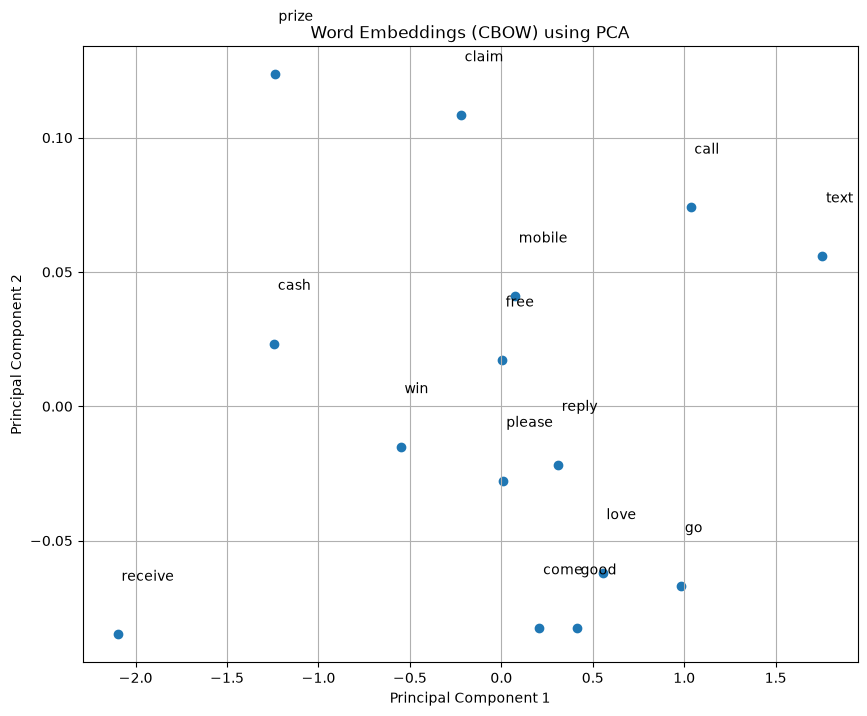

In [51]:
plt.figure(figsize=(10, 8))

plt.scatter(reduced_vectors[:, 0], reduced_vectors[:, 1])

for i, word in enumerate(words):
    plt.text(
        reduced_vectors[i, 0] + 0.02,
        reduced_vectors[i, 1] + 0.02,
        word,
        fontsize=10
    )

plt.title("Word Embeddings (CBOW) using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.grid(True)

plt.show()

### Observations

- PCA reduced the 100-dimensional word embeddings to two dimensions, making them easier to visualize.
- Words that frequently appear in similar contexts are generally located closer together in the embedding space.
- Related spam words such as **free**, **mobile**, **call**, and **text** are relatively close, indicating that the model has learned contextual relationships.
- Some words like **receive** and **prize** appear farther from the main cluster because they occur in more specific contexts within the dataset.
- Since the SMS Spam Collection dataset is relatively small, the clusters are not perfectly separated, but the visualization still demonstrates how Word2Vec captures semantic relationships.

# Task 10: Observations & Limitations

## 1. Difference between CBOW and Skip-Gram in practice

- **CBOW (Continuous Bag of Words)** predicts a target word using its surrounding context words.
- **Skip-Gram** predicts the surrounding context words from a target word.
- CBOW trains faster and performs well on large datasets, while Skip-Gram usually produces better embeddings for rare words but requires more training time.

---

## 2. Advantages of Word2Vec over TF-IDF

- Word2Vec captures semantic meaning and contextual relationships between words.
- It represents words as dense numerical vectors instead of sparse count vectors.
- Similar words are placed close together in the embedding space.
- Word2Vec can generalize relationships between words, whereas TF-IDF only measures word importance.

---

## 3. Limitations of Word2Vec

- Requires a sufficiently large corpus to learn meaningful embeddings.
- Generates a single vector for each word regardless of context.
- Cannot distinguish words with multiple meanings (polysemy).
- Training can be computationally expensive for very large datasets.

---

## 4. Why context still matters in modern NLP (Lead-in to Transformers)

- Word2Vec assigns one fixed vector to each word.
- The meaning of many words depends on the sentence in which they appear.
- Modern transformer models (such as BERT and GPT) generate context-aware embeddings, allowing the same word to have different representations depending on its usage.
- This makes transformers more effective for tasks such as question answering, translation, and text generation.